In [ ]:
# Full-Spectrum Splitting-Function PLI

Phase 1 — spectral inventory.

=== FULL PRODUCTION MODE ===
S_MAX = 4, N_BASIS = 100, N_JOBS = 8


# Full-Spectrum Splitting-Function PLI

Phase 1 — spectral inventory.

In [15]:
import sys
import os

# Ensure local helper and visualization modules are on the path.
# In Jupyter, __file__ is not defined, so use the current working directory
demo_dir = os.getcwd()
sys.path.insert(0, os.path.join(demo_dir, 'utils'))
sys.path.insert(0, os.path.join(demo_dir, 'visualization'))

import numpy as np
import matplotlib.pyplot as plt

In [16]:
# Load normal-mode data and kernels
from normal_mode_kernel_utils import NormalModeDataRegistry, NormalModeKernelCatalog
from full_spectrum_utils import enumerate_blocks, block_data_split, BlockIndex

data_dir = 'data/normal-mode-data'
kernel_dir = 'data/normal-mode-kernels/kernels-all_PREM-layers_Adrian'

print(f"Loading catalog from: {kernel_dir}")
catalog = NormalModeKernelCatalog(kernel_dir)

print(f"Loading registry from: {data_dir}")
reg = NormalModeDataRegistry(data_dir, mode_filter=catalog.list_modes())

# Set maximum splitting degree
S_MAX = 4

# Enumerate all (s, t) blocks with data
blocks = enumerate_blocks(reg, s_max=S_MAX)
print(f"Total observations: {len(reg.observations)}")
print(f"Blocks found (even s ≤ {S_MAX}): {len(blocks)}")
for b in blocks:
    print(f"  {b}: {len([obs for obs in reg.observations if obs[1] == b.s and obs[2] == b.t])} observations")

# Split data by block
split = block_data_split(reg, blocks)

Loading catalog from: data/normal-mode-kernels/kernels-all_PREM-layers_Adrian
Loading registry from: data/normal-mode-data
Total observations: 8210
Blocks found (even s ≤ 4): 15
  BlockIndex(s=0, t=0): 186 observations
  BlockIndex(s=2, t=0): 186 observations
  BlockIndex(s=2, t=1): 186 observations
  BlockIndex(s=2, t=2): 186 observations
  BlockIndex(s=2, t=3): 186 observations
  BlockIndex(s=2, t=4): 186 observations
  BlockIndex(s=4, t=0): 170 observations
  BlockIndex(s=4, t=1): 170 observations
  BlockIndex(s=4, t=2): 170 observations
  BlockIndex(s=4, t=3): 170 observations
  BlockIndex(s=4, t=4): 170 observations
  BlockIndex(s=4, t=5): 170 observations
  BlockIndex(s=4, t=6): 170 observations
  BlockIndex(s=4, t=7): 170 observations
  BlockIndex(s=4, t=8): 170 observations


In [ ]:
# Set maximum splitting degree
S_MAX = 4

from full_spectrum_utils import RadialSpecs, build_block_forward
from intervalinf import ParallelConfig

noise_multiplier = 2.0
specs = RadialSpecs(n_basis=100, parallel_cfg=ParallelConfig(enabled=True, n_jobs=12))
forward_dict = {b: build_block_forward(b.s, b.t, split[b], catalog, specs, noise_multiplier) for b in blocks}
print(f"Built {len(forward_dict)} block forward operators")
for b, (G, C_D, M, D) in sorted(forward_dict.items()):
    print(f"  Block (s={b.s},t={b.t}): N_d={D.dim}, M.dim={M.dim}")

In [18]:
from full_spectrum_utils import RadialSpecs, build_block_forward
from intervalinf import ParallelConfig

noise_multiplier = 2.0
specs = RadialSpecs(n_basis=100, parallel_cfg=ParallelConfig(enabled=True, n_jobs=12))
forward_dict = {b: build_block_forward(b.s, b.t, split[b], catalog, specs, noise_multiplier) for b in blocks}
print(f"Built {len(forward_dict)} block forward operators")
for b, (G, C_D, M, D) in sorted(forward_dict.items()):
    print(f"  Block (s={b.s},t={b.t}): N_d={D.dim}, M.dim={M.dim}")

Built 15 block forward operators
  Block (s=0,t=0): N_d=186, M.dim=2
  Block (s=2,t=0): N_d=186, M.dim=2
  Block (s=2,t=1): N_d=186, M.dim=2
  Block (s=2,t=2): N_d=186, M.dim=2
  Block (s=2,t=3): N_d=186, M.dim=2
  Block (s=2,t=4): N_d=186, M.dim=2
  Block (s=4,t=0): N_d=170, M.dim=2
  Block (s=4,t=1): N_d=170, M.dim=2
  Block (s=4,t=2): N_d=170, M.dim=2
  Block (s=4,t=3): N_d=170, M.dim=2
  Block (s=4,t=4): N_d=170, M.dim=2
  Block (s=4,t=5): N_d=170, M.dim=2
  Block (s=4,t=6): N_d=170, M.dim=2
  Block (s=4,t=7): N_d=170, M.dim=2
  Block (s=4,t=8): N_d=170, M.dim=2


## Phase 3 — Per-block prior covariance with shared Bessel-Sobolev operators

Each radial parameter ($v_p$, $v_s^{\mathrm{IC}}$, $v_s^{\mathrm{M}}$, $\rho$) has a prior covariance
$$C_{p,st} = \tau_{p,s}^2 \, C_p^{\mathrm{ref}}$$
where $C_p^{\mathrm{ref}}$ is a Bessel-Sobolev covariance built once on a reference Lebesgue space and shared across all $(s, t)$ blocks.  The spectral amplitude $\tau_{p,s} = 1$ (flat default) can be overridden per parameter and per splitting degree.

**Note:** The geophysically correct inner product uses $w(r) = r^2$ radial weighting.  This requires radial-elliptic covariances not yet implemented in intervalinf; the flat ($w = 1$) inner product is used throughout.

In [19]:
from full_spectrum_utils import (
    build_shared_bessel_blocks,
    prior_power_spectrum_default,
    build_block_prior,
)

# Build one BesselSobolevInverse per radial parameter (shared across all blocks)
shared_bessel = build_shared_bessel_blocks(specs)
print("Shared Bessel-Sobolev operators built for:", list(shared_bessel.keys()))

# Assemble per-block prior using default flat power spectrum (tau=1 for all p, s)
prior_dict = {
    block: build_block_prior(
        block.s, block.t,
        shared_bessel, specs,
        tau_fn=prior_power_spectrum_default,
        sigma_var=100.0,
    )
    for block in blocks
}

print(f"\nBuilt {len(prior_dict)} block priors")
for block, prior in sorted(prior_dict.items()):
    dim = prior.covariance.domain.dim
    print(f"  Block (s={block.s}, t={block.t}): prior domain dim = {dim}")

Shared Bessel-Sobolev operators built for: ['vp', 'vs_IC', 'vs_M', 'rho']

Built 15 block priors
  Block (s=0, t=0): prior domain dim = 2
  Block (s=2, t=0): prior domain dim = 2
  Block (s=2, t=1): prior domain dim = 2
  Block (s=2, t=2): prior domain dim = 2
  Block (s=2, t=3): prior domain dim = 2
  Block (s=2, t=4): prior domain dim = 2
  Block (s=4, t=0): prior domain dim = 2
  Block (s=4, t=1): prior domain dim = 2
  Block (s=4, t=2): prior domain dim = 2
  Block (s=4, t=3): prior domain dim = 2
  Block (s=4, t=4): prior domain dim = 2
  Block (s=4, t=5): prior domain dim = 2
  Block (s=4, t=6): prior domain dim = 2
  Block (s=4, t=7): prior domain dim = 2
  Block (s=4, t=8): prior domain dim = 2


## Phase 3.5 — Prior visualisation

:class:`PriorViewer` precomputes reference std arrays and KL sample curves for each of the
four radial parameters at τ = 1.  All interactive updates (block switch, τ slider, σ_var)
are then instant arithmetic — no operator calls happen after precomputation.

**Controls**
- **Block dropdown** — switch between (s, t) blocks
- **τ sliders** — amplitude scale per parameter; prior std ∝ τ
- **σ_var slider** (log scale) — variance of the CMB topography prior
- **Precompute button** — build reference data (needed once, or after changing specs)
- **Resample button** — redraw sample curves with a fresh random seed

In [20]:
from prior_viz import PriorViewer

viewer = PriorViewer(shared_bessel, specs, n_grid=300, n_samples=5, seed=42)

# Precompute reference std and sample curves for all four radial parameters.
# With n_basis=100 this takes ~5-15 s; a progress note is printed for each parameter.
_done = []
def _cb(p):
    _done.append(p)
    print(f"  Precomputed: {p}")

print("Precomputing prior display data…")
viewer.precompute(progress_cb=_cb)
print("Done.")

Precomputing prior display data…
  Precomputed: vp
  Precomputed: vs_IC
  Precomputed: vs_M
  Precomputed: rho
Done.


In [21]:
from prior_viz import make_prior_widget

w = make_prior_widget(viewer, blocks, specs)
display(w)

import time
from threadpoolctl import threadpool_limits
from full_spectrum_utils import solve_all_blocks

# 15 blocks (1 for s=0, 5 for s=2, 9 for s=4) on 16 cores.
# Without limits: BLAS + scipy FFT (OpenMP/FFTW) each spawn ~16 threads per
# joblib worker → hundreds of threads competing for 16 cores.
# limits=1 (no user_api filter) caps ALL detected thread pools (BLAS + OpenMP).
with threadpool_limits(limits=1):
    t0 = time.time()
    posterior_dict = solve_all_blocks(forward_dict, prior_dict, split, n_jobs=8)
    elapsed = time.time() - t0

print(f"Solved {len(posterior_dict)} blocks in {elapsed:.1f}s")
for block, post in sorted(posterior_dict.items()):
    sigma_1 = post.expectation[1][1]  # CMB topography posterior mean
    print(f"  Block (s={block.s}, t={block.t}): CMB sigma_1 mean = {sigma_1[0]:.4f}")

In [22]:
import time
from threadpoolctl import threadpool_limits
from full_spectrum_utils import solve_all_blocks

# 15 blocks (1 for s=0, 5 for s=2, 9 for s=4) on 16 cores.
# Without limits: BLAS + scipy FFT (OpenMP/FFTW) each spawn ~16 threads per
# joblib worker → hundreds of threads competing for 16 cores.
# limits=1 (no user_api filter) caps ALL detected thread pools (BLAS + OpenMP).
with threadpool_limits(limits=1):
    t0 = time.time()
    posterior_dict = solve_all_blocks(forward_dict, prior_dict, split, n_jobs=8)
    elapsed = time.time() - t0

print(f"Solved {len(posterior_dict)} blocks in {elapsed:.1f}s")
for block, post in sorted(posterior_dict.items()):
    sigma_1 = post.expectation[1][1]  # CMB topography posterior mean
    print(f"  Block (s={block.s}, t={block.t}): CMB sigma_1 mean = {sigma_1[0]:.4f}")


Solved 15 blocks in 81.9s
  Block (s=0, t=0): CMB sigma_1 mean = 9.5171
  Block (s=2, t=0): CMB sigma_1 mean = 7.3126
  Block (s=2, t=1): CMB sigma_1 mean = 9.1015
  Block (s=2, t=2): CMB sigma_1 mean = -5.9276
  Block (s=2, t=3): CMB sigma_1 mean = -20.3022
  Block (s=2, t=4): CMB sigma_1 mean = -16.8293
  Block (s=4, t=0): CMB sigma_1 mean = -0.6532
  Block (s=4, t=1): CMB sigma_1 mean = -0.1564
  Block (s=4, t=2): CMB sigma_1 mean = -0.2392
  Block (s=4, t=3): CMB sigma_1 mean = 5.0998
  Block (s=4, t=4): CMB sigma_1 mean = 0.0274
  Block (s=4, t=5): CMB sigma_1 mean = 0.6554
  Block (s=4, t=6): CMB sigma_1 mean = -0.8858
  Block (s=4, t=7): CMB sigma_1 mean = -2.4706
  Block (s=4, t=8): CMB sigma_1 mean = 0.6181


## Phase 5 — Property operators

We define 8 property targets: 3 bulk volumetric averages for (vp, vs, rho) at two
geographic locations, plus 2 antipodal CMB topography bumps. All targets use
$4\pi$-normalised real spherical harmonics (pyshtools convention). Angular bumps are
Gaussian caps with half-width $\sigma_\theta = 20°$; radial bumps are Gaussians
centred at mid-mantle ($r_0 = 4500$ km) with half-width $\sigma_r = 300$ km.

The property operator $\mathcal{T}_\mathcal{I} : \mathcal{M}_\mathcal{I} \to \mathbb{R}^{N_p}$
is a dict of per-block operators $\mathcal{T}_{st} : \mathcal{M}_{st} \to \mathbb{R}^{N_p}$.

In [23]:
from property_targets import CapBulkTarget, CapCMBTarget
from full_spectrum_utils import build_property_operator

# Property targets: 3 bulk × 2 locations + 2 CMB
targets = [
    # Bulk at Pacific (lat=10, lon=210)
    CapBulkTarget(param='vp',  lat_deg=10.0, lon_deg=210.0, cap_radius_deg=20.0, r0_km=4500.0, width_km=300.0),
    CapBulkTarget(param='vs',  lat_deg=10.0, lon_deg=210.0, cap_radius_deg=20.0, r0_km=4500.0, width_km=300.0),
    CapBulkTarget(param='rho', lat_deg=10.0, lon_deg=210.0, cap_radius_deg=20.0, r0_km=4500.0, width_km=300.0),
    # Bulk at Europe (lat=45, lon=15)
    CapBulkTarget(param='vp',  lat_deg=45.0, lon_deg=15.0, cap_radius_deg=20.0, r0_km=4500.0, width_km=300.0),
    CapBulkTarget(param='vs',  lat_deg=45.0, lon_deg=15.0, cap_radius_deg=20.0, r0_km=4500.0, width_km=300.0),
    CapBulkTarget(param='rho', lat_deg=45.0, lon_deg=15.0, cap_radius_deg=20.0, r0_km=4500.0, width_km=300.0),
    # CMB topography: antipodal pair
    CapCMBTarget(lat_deg=0.0, lon_deg=0.0, cap_radius_deg=20.0),
    CapCMBTarget(lat_deg=0.0, lon_deg=180.0, cap_radius_deg=20.0),
]

property_op_dict = build_property_operator(targets, blocks, forward_dict, specs, s_max=S_MAX)
print(f"Built property operators for {len(property_op_dict)} blocks, N_p = {len(targets)}")

# Sanity check: apply to posterior mean for one block
test_block = sorted(property_op_dict.keys())[0]
T_test = property_op_dict[test_block]
mu_test = posterior_dict[test_block].expectation
props = T_test(mu_test)
print(f"\nBlock (s={test_block.s}, t={test_block.t}) property vector:")
for i, (target, val) in enumerate(zip(targets, props)):
    print(f"  Property {i} ({type(target).__name__}): {val:.6f}")

Built property operators for 15 blocks, N_p = 8

Block (s=0, t=0) property vector:
  Property 0 (CapBulkTarget): 0.005963
  Property 1 (CapBulkTarget): 0.003818
  Property 2 (CapBulkTarget): 0.003072
  Property 3 (CapBulkTarget): 0.005963
  Property 4 (CapBulkTarget): 0.003818
  Property 5 (CapBulkTarget): 0.003072
  Property 6 (CapCMBTarget): 0.757348
  Property 7 (CapCMBTarget): 0.757348


## Phase 6 — Full property posterior $\mathcal{N}(\mu_P, C_P)$

The property posterior is assembled by pushing each block's model posterior through the
corresponding property operator and summing:

$$\mu_P = \sum_{(s,t)} \mathcal{T}_{st}(\tilde{m}_{st}), \qquad
C_P = \sum_{(s,t)} \mathcal{T}_{st}\, C^{\mathrm{post}}_{st}\, \mathcal{T}_{st}^*$$

This is a dense $N_p \times N_p$ Gaussian on $\mathbb{R}^{N_p}$, with cost
$O(N_p \cdot |\mathcal{I}|)$ covariance applies.

Property posterior mean and std:
  CapBulkTarget(param=vp)                 : mu=0.0098, sigma=0.0151
  CapBulkTarget(param=vs)                 : mu=0.0223, sigma=0.0095
  CapBulkTarget(param=rho)                : mu=-0.0013, sigma=0.0079
  CapBulkTarget(param=vp)                 : mu=0.0135, sigma=0.0151
  CapBulkTarget(param=vs)                 : mu=0.0052, sigma=0.0094
  CapBulkTarget(param=rho)                : mu=0.0085, sigma=0.0079
  CapCMBTarget()                          : mu=-3.5387, sigma=0.2626
  CapCMBTarget()                          : mu=-3.5387, sigma=0.2626


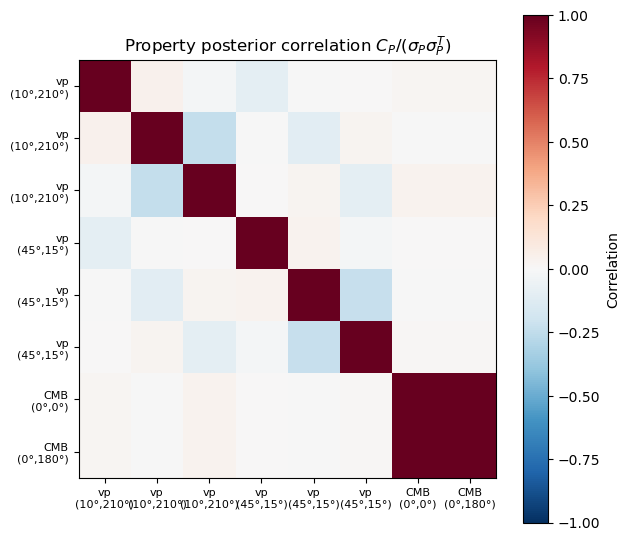

Figure saved to property_posterior_correlation.png


In [24]:
from full_spectrum_utils import assemble_property_posterior
import matplotlib.pyplot as plt

# Assemble full property posterior
property_posterior = assemble_property_posterior(property_op_dict, posterior_dict)
mu_P = property_posterior.expectation

# Extract dense covariance matrix
N_p = len(targets)
C_P = np.zeros((N_p, N_p))
for j in range(N_p):
    e_j = np.zeros(N_p); e_j[j] = 1.0
    C_P[:, j] = property_posterior.covariance(e_j)

sigma_P = np.sqrt(np.diag(C_P))

print("Property posterior mean and std:")
target_names = [
    f"{type(t).__name__}({'param='+t.param if hasattr(t,'param') else ''})"
    for t in targets
]
for name, mu, sig in zip(target_names, mu_P, sigma_P):
    print(f"  {name:40s}: mu={mu:.4f}, sigma={sig:.4f}")

# Correlation heatmap
corr_P = C_P / np.outer(sigma_P, sigma_P)

short_names = [
    (f"vp" if hasattr(t, 'param') else "CMB") +
    (f"\n({t.lat_deg:.0f}°,{t.lon_deg:.0f}°)" if hasattr(t, 'lat_deg') else '')
    for t in targets
]

fig, ax = plt.subplots(figsize=(max(6, N_p * 0.8), max(5, N_p * 0.7)))
im = ax.imshow(corr_P, vmin=-1, vmax=1, cmap='RdBu_r')
plt.colorbar(im, ax=ax, label='Correlation')
ax.set_xticks(range(N_p)); ax.set_xticklabels(short_names, fontsize=8)
ax.set_yticks(range(N_p)); ax.set_yticklabels(short_names, fontsize=8)
ax.set_title(r'Property posterior correlation $C_P / (\sigma_P \sigma_P^T)$')
plt.tight_layout()
fig.savefig('property_posterior_correlation.png', dpi=150)
plt.show()
print("Figure saved to property_posterior_correlation.png")

## Phase 7 — Visualisation and Reporting

Four headline figures: per-block radial posterior fields, CMB topography map,
an optional equatorial slice (disabled by default), and a property posterior
summary (bar chart + correlation heatmap).

Figure 1 saved to block_posterior_s2t0.png


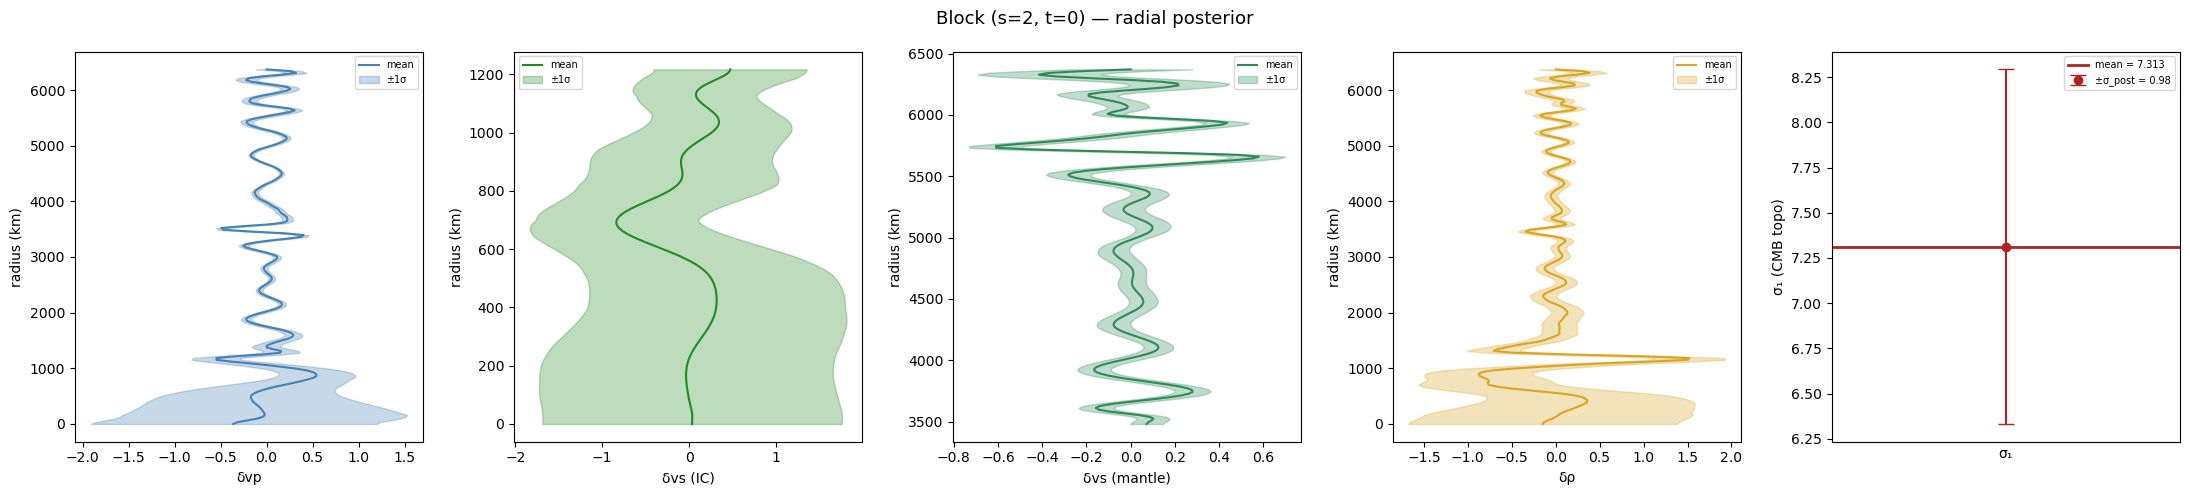

In [ ]:
from full_spectrum_viz import (
    plot_block_posterior, plot_cmb_map,
    plot_equatorial_slice, plot_property_posterior_summary,
)

# Figure 1: representative (2, 0) block radial posteriors
rep_block = BlockIndex(s=2, t=0)
fig1 = plot_block_posterior(rep_block, posterior_dict[rep_block], forward_dict, specs)
fig1.savefig('block_posterior_s2t0.png', dpi=150)
print("Figure 1 saved to block_posterior_s2t0.png")

Figure 2 saved to cmb_topography_map.png
Figure 3: equatorial slice disabled (set enabled=True to compute)


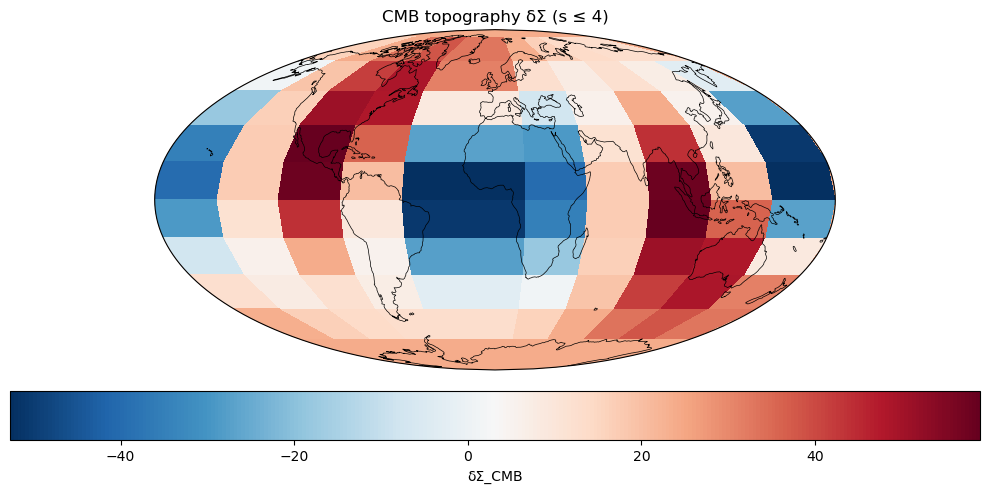

In [26]:
# Figure 2: CMB topography map
fig2 = plot_cmb_map(blocks, posterior_dict, S_MAX)
fig2.savefig('cmb_topography_map.png', dpi=150)
print("Figure 2 saved to cmb_topography_map.png")

# Figure 3: equatorial slice (disabled by default — set enabled=True to compute)
fig3 = plot_equatorial_slice(blocks, posterior_dict, S_MAX, param='vs', enabled=False)
if fig3 is not None:
    fig3.savefig('equatorial_slice_vs.png', dpi=150)
    print("Figure 3 saved to equatorial_slice_vs.png")
else:
    print("Figure 3: equatorial slice disabled (set enabled=True to compute)")

Figure 4 saved to property_posterior_summary.png


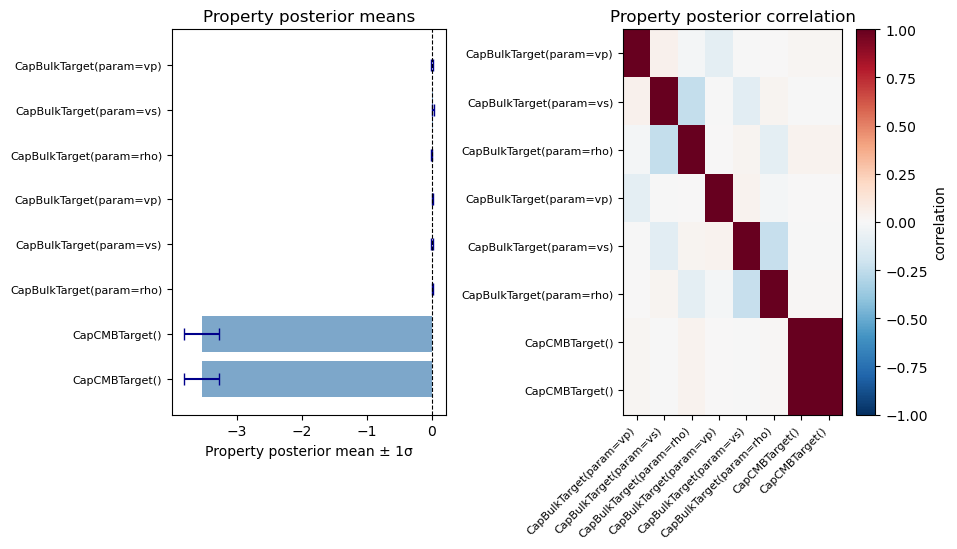

In [27]:
# Figure 4: property posterior summary
fig4 = plot_property_posterior_summary(mu_P, sigma_P, corr_P, target_names)
fig4.savefig('property_posterior_summary.png', dpi=150)
print("Figure 4 saved to property_posterior_summary.png")